# FFT_sine.ipynb

Fourier transforming a noisy sine function

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt, f_s, N = 0.1, 0.1, 3000 # time-step, frequency, number of time-steps
T = dt * N # total time interval
t = np.arange(0,T,dt) 
N = len(t)
print(N) # = 3000; 3049 would be a prime but still works w/fft()

# set up time series y(t):
y = np.sin(2 * np.pi * f_s * t)
# set up frequency vector:
f = np.linspace(0,(N-1)/T,N)

# take the Fourier transform using FFT:
Y_clean = np.fft.fft(y)
P_clean = np.abs(Y_clean)**2 # power

np.random.seed(0)

# add Gaussian noise to time series:
y_noisy = y + np.random.randn(N)*5

Y_noisy = np.fft.fft(y_noisy)
P_noisy = np.abs(Y_noisy)**2

3000


In [3]:
plt.rcParams.update({'font.size': 21})

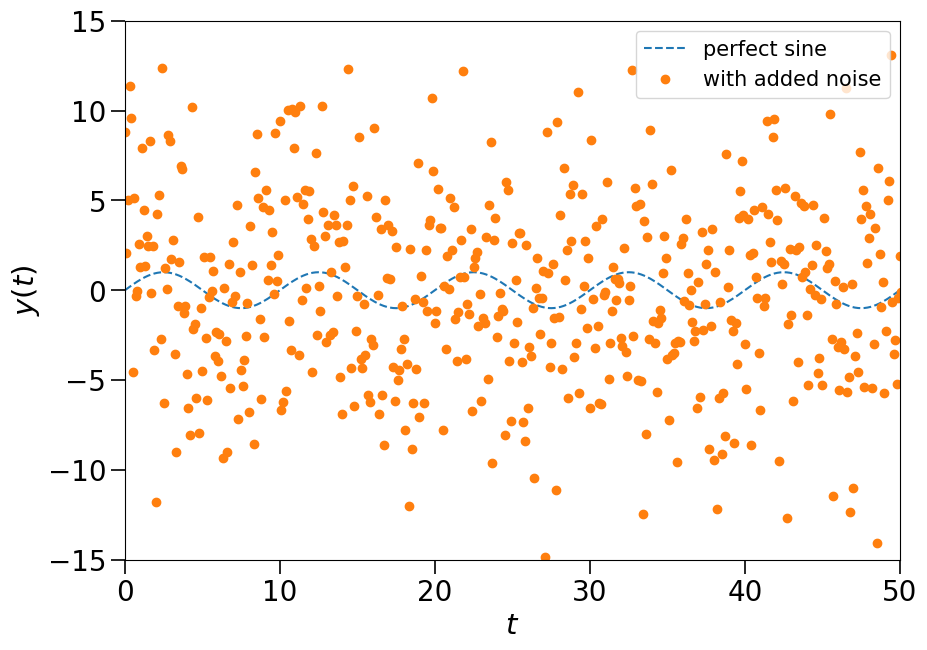

In [4]:
fig1 = plt.figure(figsize=(10,7))
plt.plot(t,y,'--',label='perfect sine')
plt.plot(t,y_noisy,'o',label='with added noise')
plt.xlabel('$t$')
plt.ylabel('$y(t)$')
plt.xlim(0,50)
plt.ylim(-15,15)
plt.tick_params('both', length=10, width=1.2, which='major', labelsize=20)
#plt.grid('on')
plt.legend(loc='best',fontsize=15)
#plt.savefig('FFT_sine_fig1.png')

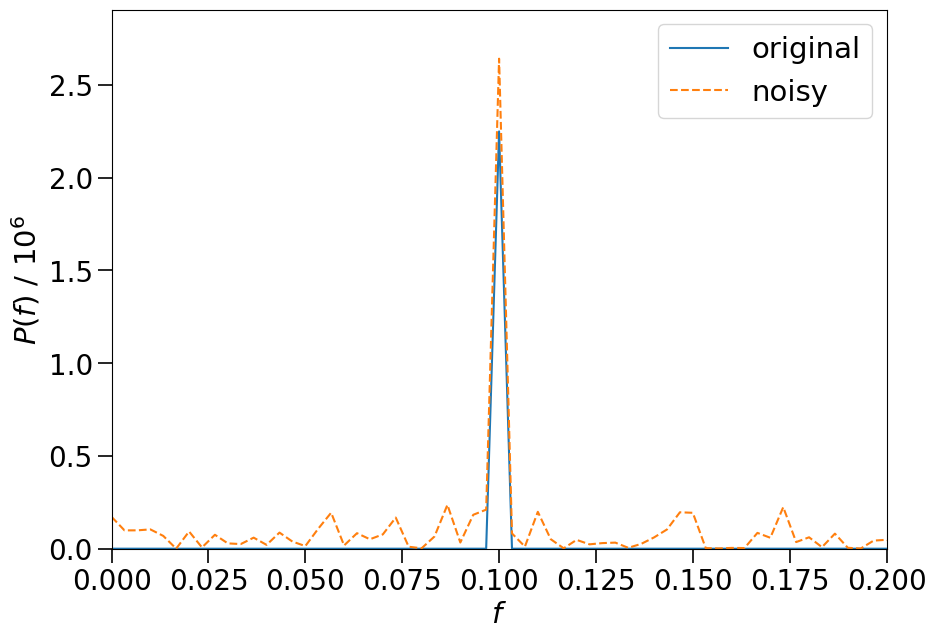

In [5]:
fig2 = plt.figure(figsize=(10,7))
#plt.plot(f,P_clean/1e6) 
#plt.plot(f,P_noisy/1e6) 
plt.plot(f[:int(N/2)],P_clean[:int(N/2)]/1e6,label='original') # cut off the aliasing
plt.plot(f[:int(N/2)],P_noisy[:int(N/2)]/1e6,'--',label='noisy') # cut off the aliasing
plt.xlabel('$f$')
plt.ylabel('$P(f) \,\, / \,\, 10^6$')
plt.tick_params('both', length=10, width=1.2, which='major', labelsize=20)
#plt.grid('on')
plt.xlim(0,0.2) # 5)
plt.ylim(0,max(P_noisy)/1e6*1.1)
plt.legend(loc='best')
#plt.savefig('FFT_sine_fig2.png')